In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,roc_auc_score
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("spam.csv", encoding="latin-1")

print(df.shape)
print(df.columns.tolist())
print(df.head())

(5572, 5)
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [6]:
df = df.rename(columns={'v1': 'label', 'v2': 'text'})
df.head()

,label,text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df = df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
df.isnull().sum()

,0
label,0
text,0


In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (5169, 2)


In [14]:
df['label'].value_counts()

,count
label,
ham,4516
spam,653


In [16]:
l = LabelEncoder()
df['label'] = l.fit_transform(df['label'])
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text
df["clean_text"] = df["text"].apply(clean_text)
print(df[["text", "clean_text"]].head(10))

                                                text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   
5  FreeMsg Hey there darling it's been 3 week's n...   
6  Even my brother is not like to speak with me. ...   
7  As per your request 'Melle Melle (Oru Minnamin...   
8  WINNER!! As a valued network customer you have...   
9  Had your mobile 11 months or more? U R entitle...   

                                          clean_text  
0  go until jurong point crazy available only in ...  
1                            ok lar joking wif u oni  
2  free entry in a wkly comp to win fa cup final ...  
3        u dun say so early hor u c already then say  
4  nah i dont think he goes to usf he lives aroun...  
5  freemsg hey there darling its been weeks now a... 

In [21]:
df.head()

,label,text,clean_text
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [22]:
x = df.drop(["label", "text"], axis=1)
y = df["label"]

In [24]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [25]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)
x_train = tfidf.fit_transform(x_train["clean_text"])
x_test = tfidf.transform(x_test["clean_text"])

In [26]:
print(tfidf.get_feature_names_out()[:20])

['aah' 'abi' 'abiola' 'able' 'able to' 'about' 'about it' 'about me'
 'about smiling' 'about stuff' 'about that' 'about the' 'about this'
 'about to' 'about you' 'about your' 'abt' 'ac' 'accept' 'access']


In [29]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
lr_prob = lr_model.predict_proba(x_test)[:,1]
accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred)
recall = recall_score(y_test, lr_pred)
f1 = f1_score(y_test, lr_pred)
roc_auc = roc_auc_score(y_test, lr_prob)

print("Logistic Regression Results")
print("=" * 35)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
Accuracy : 0.9632
Precision: 0.9895
Recall   : 0.7176
F1 Score : 0.8319
ROC-AUC  : 0.9872


In [30]:
print(classification_report(
    y_test,
    lr_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       0.99      0.72      0.83       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.96      0.96      0.96      1034



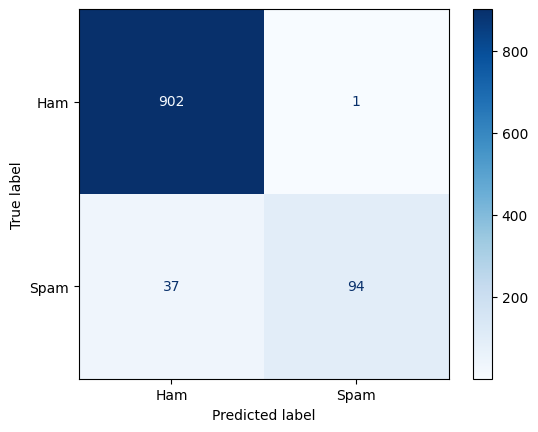

In [31]:
cm = confusion_matrix(y_test, lr_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues, values_format="d")

In [41]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
rf_prob = rf_model.predict_proba(x_test)[:,1]
accuracy_rf = accuracy_score(y_test, rf_pred)
precision_rf = precision_score(y_test, rf_pred)
recall_rf = recall_score(y_test, rf_pred)
f1_rf = f1_score(y_test, rf_pred)
roc_auc_rf = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("=" *35)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

Random Forest Results
Accuracy : 0.9739
Precision: 0.9906
Recall   : 0.8015
F1 Score : 0.8861
ROC-AUC  : 0.9897


In [34]:
print(classification_report(y_test,rf_pred,target_names=["Ham","Spam"]))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       903
        Spam       0.99      0.80      0.89       131

    accuracy                           0.97      1034
   macro avg       0.98      0.90      0.94      1034
weighted avg       0.97      0.97      0.97      1034



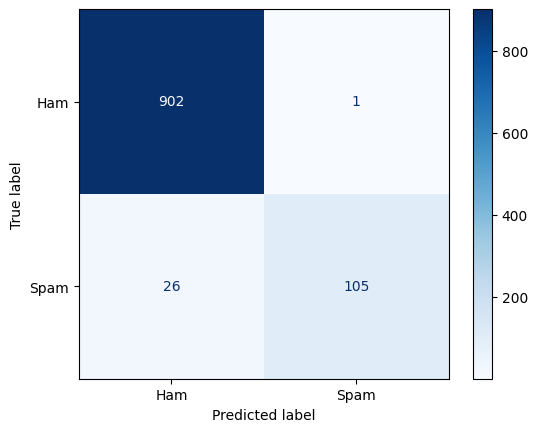

In [37]:
cm = confusion_matrix(y_test, rf_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues, values_format="d")

In [40]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(x_train, y_train)
nb_pred = nb_model.predict(x_test)
nb_prob = nb_model.predict_proba(x_test)[:,1]
accuracy_nb = accuracy_score(y_test, nb_pred)
precision_nb = precision_score(y_test, nb_pred)
recall_nb = recall_score(y_test, nb_pred)
f1_nb = f1_score(y_test, nb_pred)
roc_auc_nb = roc_auc_score(y_test, nb_prob)

print("Naive Bayes Results")
print("=" *35)
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")
print(f"ROC-AUC  : {roc_auc_nb:.4f}")

Naive Bayes Results
Accuracy : 0.9642
Precision: 1.0000
Recall   : 0.7176
F1 Score : 0.8356
ROC-AUC  : 0.9810


In [36]:
print(classification_report(y_test,nb_pred,target_names=["Ham","Spam"]))

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       903
        Spam       1.00      0.72      0.84       131

    accuracy                           0.96      1034
   macro avg       0.98      0.86      0.91      1034
weighted avg       0.97      0.96      0.96      1034



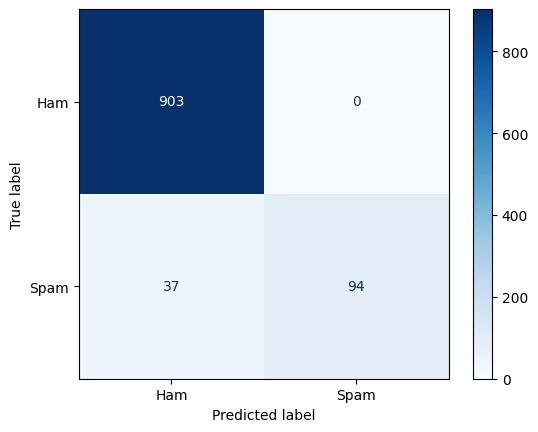

In [38]:
cm = confusion_matrix(y_test, nb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues, values_format="d")

In [42]:
results = {
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "RandomForestClassifier"
    ],
    "Accuracy": [
        accuracy,
        accuracy_nb,
        accuracy_rf
    ],
    "Precision": [
        precision,
        precision_nb,
        precision_rf
    ],
    "Recall": [
        recall,
        recall_nb,
        recall_rf
    ],
    "F1": [
        f1,
        f1_nb,
        f1_rf
    ],
    "ROC-AUC": [
        roc_auc,
        roc_auc_nb,
        roc_auc_rf
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

                    Model  Accuracy  Precision    Recall        F1   ROC-AUC
0     Logistic Regression  0.964217   1.000000  0.717557  0.835556  0.981017
1             Naive Bayes  0.964217   1.000000  0.717557  0.835556  0.981017
2  RandomForestClassifier  0.973888   0.990566  0.801527  0.886076  0.989682


In [44]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20, 25],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Best CV F1:
0.8877334482899324


In [45]:
best_rf = random_search.best_estimator_

y_pred_tuned = best_rf.predict(x_test)
y_prob_tuned = best_rf.predict_proba(x_test)[:, 1]

In [46]:
print("Tuned Random Forest")
print("=" * 35)
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_tuned):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_tuned):.4f}")

Tuned Random Forest
Accuracy : 0.9729
Precision: 0.9402
Recall   : 0.8397
F1 Score : 0.8871
ROC-AUC  : 0.9761


In [47]:
print(classification_report(y_test,y_pred_tuned,target_names=["Ham","Spam"]))

              precision    recall  f1-score   support

         Ham       0.98      0.99      0.98       903
        Spam       0.94      0.84      0.89       131

    accuracy                           0.97      1034
   macro avg       0.96      0.92      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [51]:
def predict_spam(message):
    message_tfidf = tfidf.transform([message])
    prediction = best_rf.predict(message_tfidf)[0]
    probability = best_rf.predict_proba(message_tfidf)[0][1]

    if prediction == 1:
        print("🚨 SPAM")
        print(f"Spam Probability: {probability:.2%}")
    else:
        print("✅ HAM (Not Spam)")
        print(f"Spam Probability: {probability:.2%}")

predict_spam(
    "URGENT! You have won £1000. Call now to claim your reward."
)

🚨 SPAM
Spam Probability: 86.41%
